In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
magic_gamma_telescope = fetch_ucirepo(id=159) 
  
# data (as pandas dataframes) 
dataset = magic_gamma_telescope.data.features 
y = magic_gamma_telescope.data.targets 
  
# metadata 
print(magic_gamma_telescope.metadata) 
  
# variable information 
print(magic_gamma_telescope.variables) 


{'uci_id': 159, 'name': 'MAGIC Gamma Telescope', 'repository_url': 'https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope', 'data_url': 'https://archive.ics.uci.edu/static/public/159/data.csv', 'abstract': 'Data are MC generated to simulate registration of high energy gamma particles in an atmospheric Cherenkov telescope', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 19020, 'num_features': 10, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2004, 'last_updated': 'Tue Dec 19 2023', 'dataset_doi': '10.24432/C52C8B', 'creators': ['R. Bock'], 'intro_paper': None, 'additional_info': {'summary': "The data are MC generated (see below) to simulate registration of high energy gamma particles in a ground-based atmospheric Cherenkov gamma telescope using the imaging technique. Cherenkov gamm

In [6]:
dataset.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620


In [7]:
print("Shape:", dataset.shape)
print("\nColumns:")
print(dataset.columns.tolist())
print("\nData types:")
print(dataset.dtypes)

Shape: (19020, 10)

Columns:
['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist']

Data types:
fLength     float64
fWidth      float64
fSize       float64
fConc       float64
fConc1      float64
fAsym       float64
fM3Long     float64
fM3Trans    float64
fAlpha      float64
fDist       float64
dtype: object


In [8]:
missing = dataset.isnull().sum()
numeric_check = dataset.apply(lambda s: pd.api.types.is_numeric_dtype(s)).all()

print("Missing values per column:")
print(missing)

print("All columns numeric:", numeric_check)

Missing values per column:
fLength     0
fWidth      0
fSize       0
fConc       0
fConc1      0
fAsym       0
fM3Long     0
fM3Trans    0
fAlpha      0
fDist       0
dtype: int64
All columns numeric: True


In [9]:
duplicates = dataset.duplicated()
print("\nNumber of duplicate rows:", duplicates.sum())
print(dataset[duplicates])


Number of duplicate rows: 115
        fLength   fWidth   fSize   fConc  fConc1     fAsym   fM3Long  \
12827  202.8290  73.9967  4.3622  0.0678  0.0364  -66.4079 -159.3540   
13332   30.1721  16.8838  2.6902  0.4673  0.2704    8.8759   25.3694   
13486   69.7676  18.9821  2.7478  0.5255  0.2654  -44.5832  -30.7591   
14150  130.3080  13.3030  2.6021  0.3250  0.1812 -204.5730  116.0500   
14160   16.9894  11.0002  2.4564  0.6294  0.3514   -3.4902    8.0823   
...         ...      ...     ...     ...     ...       ...       ...   
18809   60.5328  34.9208  3.0436  0.2732  0.1750  -39.5703   45.4899   
18826   38.7641  20.0218  2.6279  0.2921  0.1543  -49.9354  -21.7010   
18831   22.2134  18.3853  2.5653  0.4354  0.2599  -16.5600   16.1254   
18929   19.8489  12.8985  2.3847  0.5567  0.3155  -12.1732  -10.7301   
19001   57.1905  35.5095  2.7177  0.2337  0.1197  -48.5112  -54.2835   

       fM3Trans   fAlpha     fDist  
12827  -21.2584  76.1130  348.9780  
13332   14.0300  74.7090  229.

In [10]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
fLength,19020.0,53.250154,42.364855,4.2835,24.336000,37.14770,70.122175,334.1770
fWidth,19020.0,22.180966,18.346056,0.0000,11.863800,17.13990,24.739475,256.3820
fSize,19020.0,2.825017,0.472599,1.9413,2.477100,2.73960,3.101600,5.3233
fConc,19020.0,0.380327,0.182813,0.0131,0.235800,0.35415,0.503700,0.8930
fConc1,19020.0,0.214657,0.110511,0.0003,0.128475,0.19650,0.285225,0.6752
fAsym,19020.0,-4.331745,59.206062,-457.9161,-20.586550,4.01305,24.063700,575.2407
fM3Long,19020.0,10.545545,51.000118,-331.7800,-12.842775,15.31410,35.837800,238.3210
fM3Trans,19020.0,0.249726,20.827439,-205.8947,-10.849375,0.66620,10.946425,179.8510
fAlpha,19020.0,27.645707,26.103621,0.0000,5.547925,17.67950,45.883550,90.0000
fDist,19020.0,193.818026,74.731787,1.2826,142.492250,191.85145,240.563825,495.5610


## 7. Target Overview and Class Balance
We inspect target structure and class balance before deeper feature analysis.

In [11]:
# Normalize target to a 1D series
target = y.iloc[:, 0] if isinstance(y, pd.DataFrame) else y
target = target.rename("target")

print("Target dtype:", target.dtype)
print("Target unique values:", target.unique())
print("\nClass distribution:")
class_counts = target.value_counts()
print(class_counts)

class_ratio = class_counts / class_counts.sum()
print("\nClass ratio:")
print(class_ratio)

# Merge for class-conditional EDA
df_eda = dataset.copy()
df_eda["target"] = target.values

Target dtype: object
Target unique values: ['g' 'h']

Class distribution:
target
g    12332
h     6688
Name: count, dtype: int64

Class ratio:
target
g    0.64837
h    0.35163
Name: count, dtype: float64


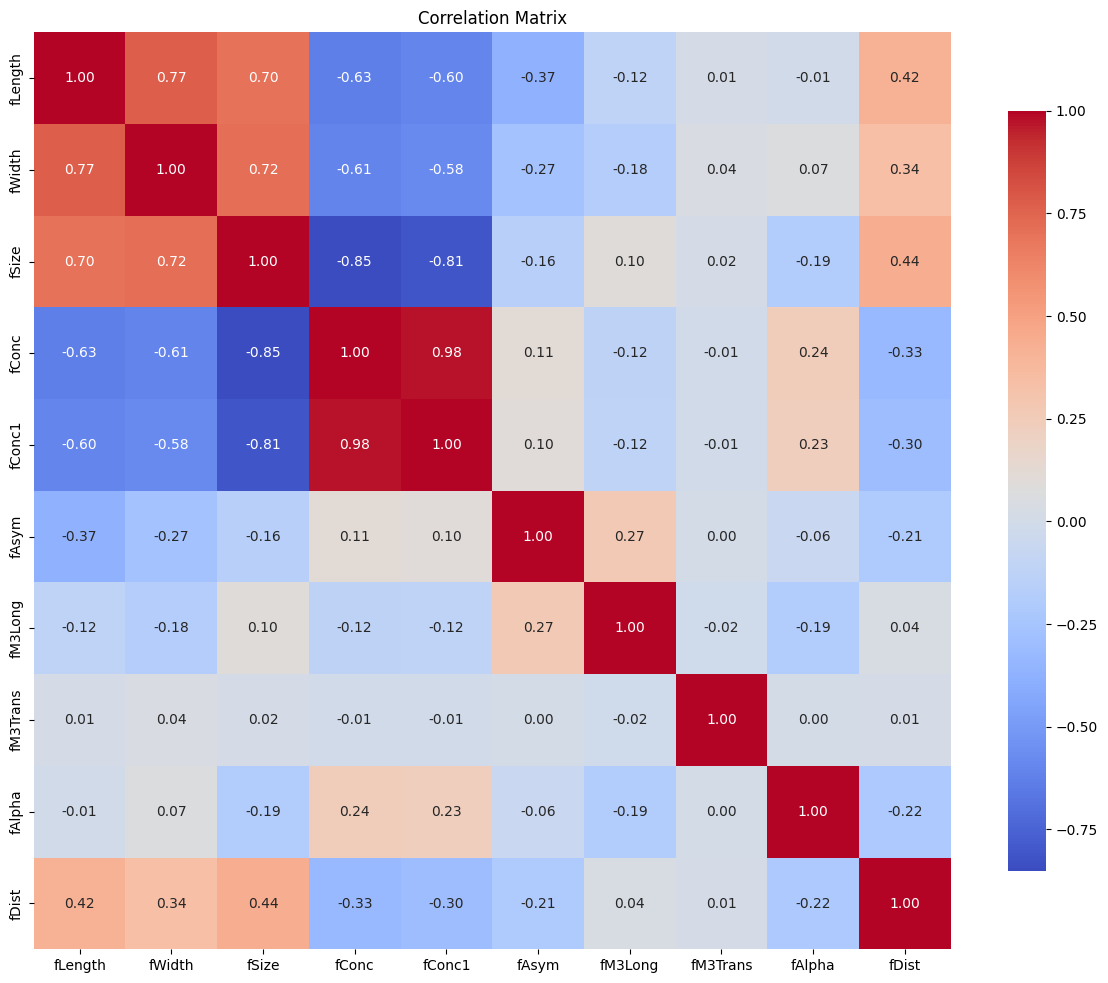

In [12]:
corr = dataset.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 8. Strongest Correlated Feature Pairs
We list the strongest absolute correlations to spot possible multicollinearity.

In [13]:
corr_abs = corr.abs()
upper_triangle = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
top_pairs = upper_triangle.stack().sort_values(ascending=False).head(10)

print("Top 10 strongest absolute correlations:")
print(top_pairs)

Top 10 strongest absolute correlations:
fConc    fConc1    0.976412
fSize    fConc     0.850850
         fConc1    0.808835
fLength  fWidth    0.770512
fWidth   fSize     0.717517
fLength  fSize     0.702454
         fConc     0.630999
fWidth   fConc     0.609779
fLength  fConc1    0.598145
fWidth   fConc1    0.581141
dtype: float64


## 9. Class-Conditional Distributions
We compare feature distributions by class to see which variables separate gamma and hadron events better.

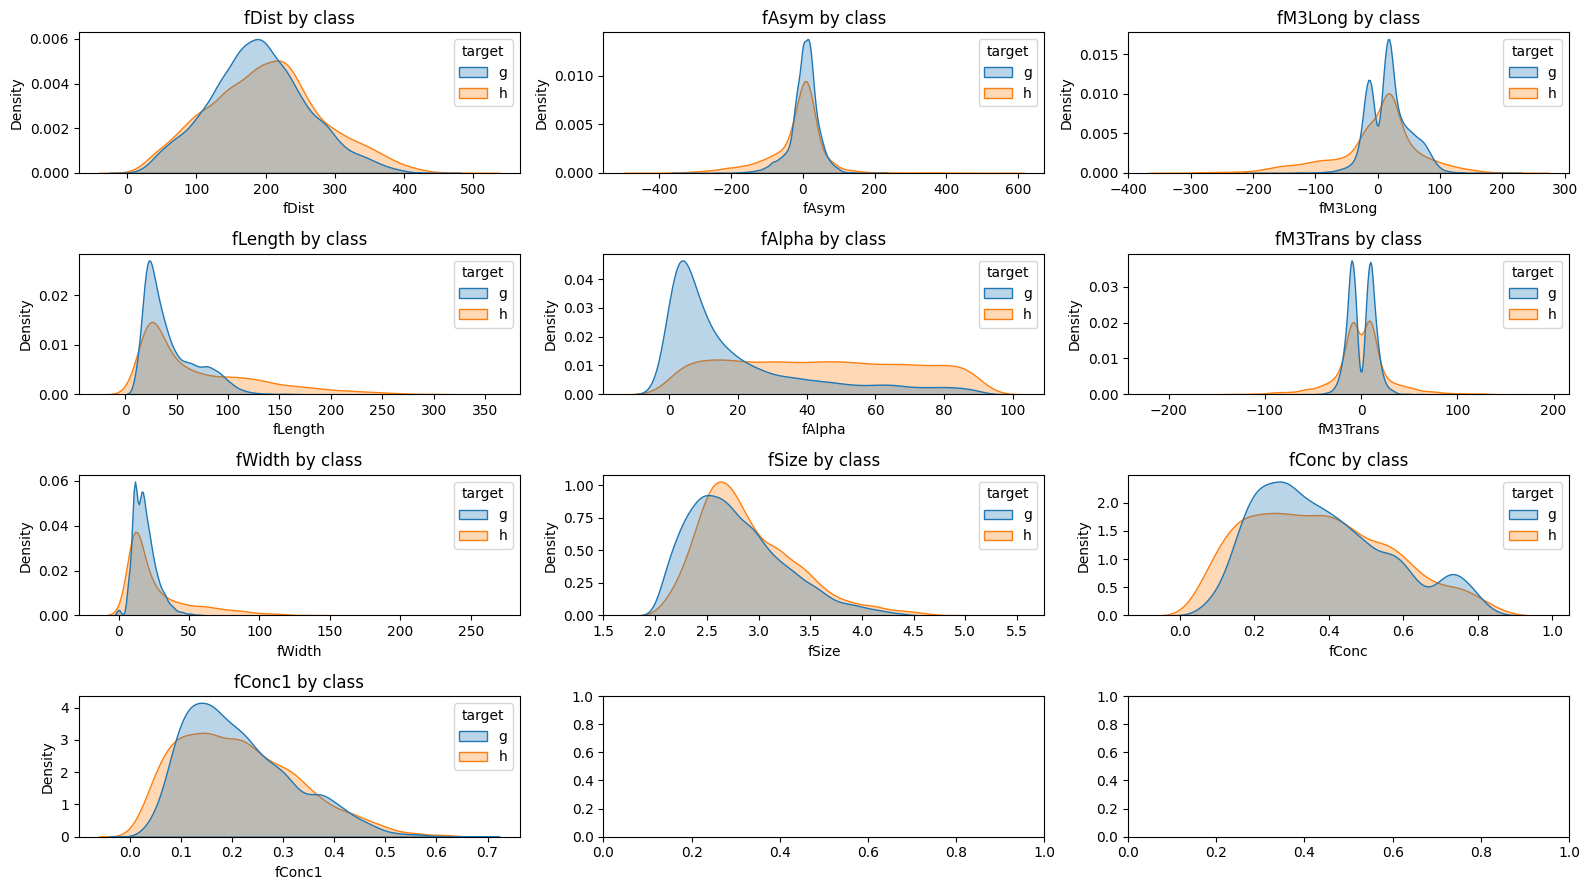

In [20]:
# Use variance to pick informative features for quick visualization
top_features = dataset.var().sort_values(ascending=False).head(10).index.tolist()

fig, axes = plt.subplots(4, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), top_features):
    sns.kdeplot(data=df_eda, x=col, hue="target", fill=True, common_norm=False, alpha=0.3, ax=ax)
    ax.set_title(f"{col} by class")

plt.tight_layout()
plt.show()

## 10. Outlier Check (IQR)
We estimate potential outlier share per feature using the IQR rule.

In [21]:
iqr_stats = []
for col in dataset.columns:
    q1 = dataset[col].quantile(0.25)
    q3 = dataset[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_mask = (dataset[col] < lower) | (dataset[col] > upper)
    iqr_stats.append({
        "feature": col,
        "outlier_count": int(outlier_mask.sum()),
        "outlier_pct": float(outlier_mask.mean() * 100)
    })

outlier_df = pd.DataFrame(iqr_stats).sort_values("outlier_pct", ascending=False)
outlier_df.head(10)

,feature,outlier_count,outlier_pct
5,fAsym,1781,9.363828
1,fWidth,1546,8.128286
6,fM3Long,1218,6.403785
0,fLength,971,5.105152
7,fM3Trans,850,4.468980
2,fSize,367,1.929548
4,fConc1,150,0.788644
9,fDist,128,0.672976
3,fConc,0,0.000000
8,fAlpha,0,0.000000


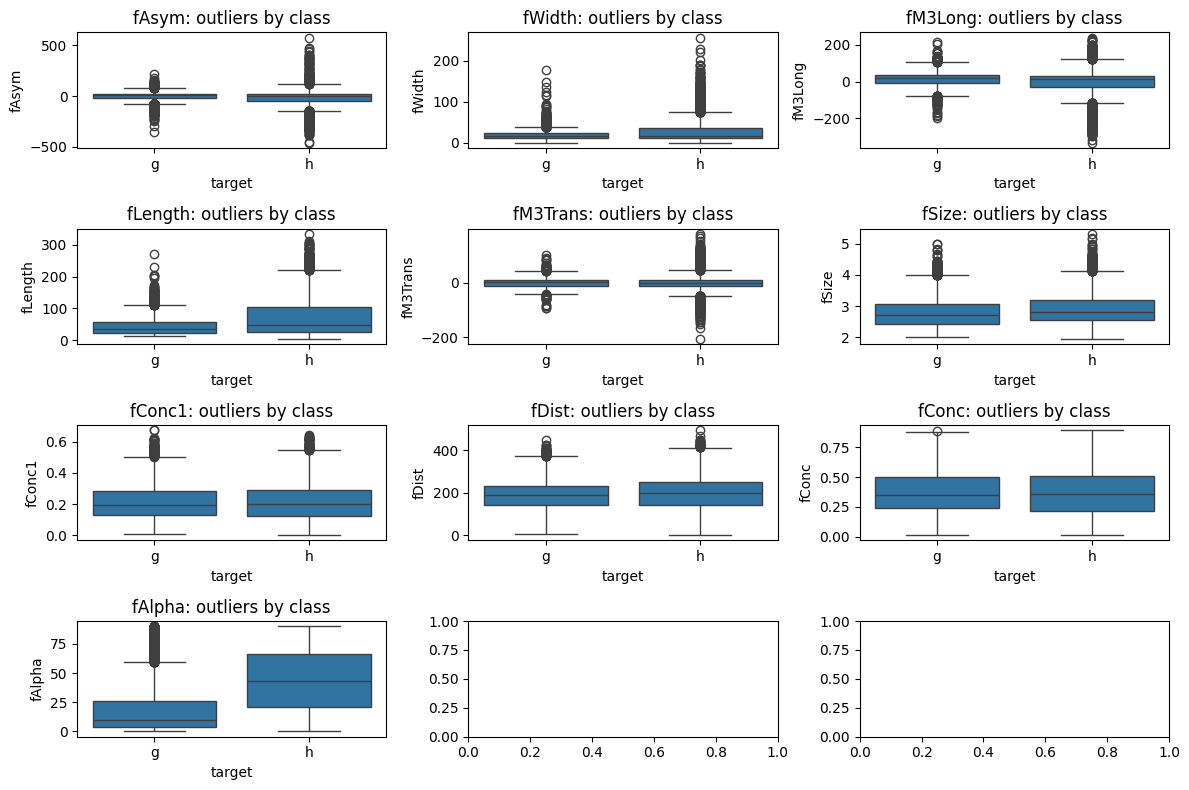

In [23]:
# Boxplots for top outlier-heavy features
top_outlier_features = outlier_df.head(10)["feature"].tolist()

fig, axes = plt.subplots(4, 3, figsize=(12, 8))
for ax, col in zip(axes.flatten(), top_outlier_features):
    sns.boxplot(data=df_eda, x="target", y=col, ax=ax)
    ax.set_title(f"{col}: outliers by class")

plt.tight_layout()
plt.show()

## 11. EDA Summary
- Dataset appears numerically consistent for modeling-oriented analysis.
- Class distribution should be checked for imbalance before model training.
- Correlated feature pairs indicate possible multicollinearity.
- Class-conditional density and boxplots show which variables separate classes best.
- Outlier-heavy features may benefit from robust scaling or transformation.